In [ ]:
import pandas as pd

In [ ]:
links = pd.read_csv('/content/drive/MyDrive/Datasets/ml-latest-small/links.csv')
movies = pd.read_csv('/content/drive/MyDrive/Datasets/ml-latest-small/movies.csv')
ratings = pd.read_csv('/content/drive/MyDrive/Datasets/ml-latest-small/ratings.csv')
tags = pd.read_csv('/content/drive/MyDrive/Datasets/ml-latest-small/tags.csv')

df1 = pd.merge(ratings, movies, on= 'movieId', how = 'left')
df2 = pd.merge(df1, tags, on = 'movieId', how = 'left')
df = pd.merge(df2, tags, on= 'movieId', how = 'left')

df.head()

,userId_x,movieId,rating,timestamp_x,title,genres,userId_y,tag_x,timestamp_y,userId,tag_y,timestamp
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,336.0,pixar,1.139046e+09,336.0,pixar,1.139046e+09
1,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,336.0,pixar,1.139046e+09,474.0,pixar,1.137207e+09
2,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,336.0,pixar,1.139046e+09,567.0,fun,1.525286e+09
3,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,474.0,pixar,1.137207e+09,336.0,pixar,1.139046e+09
4,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,474.0,pixar,1.137207e+09,474.0,pixar,1.137207e+09


In [ ]:
#Checking for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

#Checking for missing values
missing = df.isnull().sum()
print("Missing values per column: ")
print(missing)


Number of duplicate rows: 0
Missing values per column: 
userId_x           0
movieId            0
rating             0
timestamp_x        0
title              0
genres             0
userId_y       52549
tag_x          52549
timestamp_y    52549
userId         52549
tag_y          52549
timestamp      52549
dtype: int64


In [ ]:
df = df.drop(['userId_y', 'tag_x', 'timestamp_y', 'userId', 'tag_y', 'timestamp'], axis=1)


df = df.rename(columns={
    'userId_x': 'userId',
    'timestamp_x': 'timestamp'
})


In [ ]:
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
3,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
4,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy


In [ ]:

df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')


In [ ]:
df['timestamp'].head()

,timestamp
0,2000-07-30 18:45:03
1,2000-07-30 18:45:03
2,2000-07-30 18:45:03
3,2000-07-30 18:45:03
4,2000-07-30 18:45:03


In [ ]:
import re

# 1. Extracting release year from title
df['release_year'] = df['title'].str.extract(r'\((\d{4})\)').astype(float)

# 2. Counting number of genres
df['num_genres'] = df['genres'].apply(lambda x: len(x.split('|')) if pd.notnull(x) else 0)

# 3. Extracting main (first) genre
df['main_genre'] = df['genres'].apply(lambda x: x.split('|')[0] if pd.notnull(x) else None)

df[['title', 'genres', 'release_year', 'num_genres', 'main_genre']].head()


,title,genres,release_year,num_genres,main_genre
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,Adventure
1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,Adventure
2,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,Adventure
3,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,Adventure
4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,Adventure


In [ ]:
# 4. Extracting the rating year from timestamp
df['rating_year'] = df['timestamp'].dt.year

# 5. Calculating movie age at the time of rating
df['movie_age'] = df['rating_year'] - df['release_year']

# 6. Creating an "is_classic" feature: 1 if movie_age > 20 years, else 0
df['is_classic'] = df['movie_age'].apply(lambda x: 1 if x > 20 else 0)

df[['title', 'release_year', 'rating_year', 'movie_age', 'is_classic']].head()


,title,release_year,rating_year,movie_age,is_classic
0,Toy Story (1995),1995.0,2000,5.0,0
1,Toy Story (1995),1995.0,2000,5.0,0
2,Toy Story (1995),1995.0,2000,5.0,0
3,Toy Story (1995),1995.0,2000,5.0,0
4,Toy Story (1995),1995.0,2000,5.0,0


In [ ]:
df

,userId,movieId,rating,timestamp,title,genres,release_year,num_genres,main_genre,rating_year,movie_age,is_classic
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,Adventure,2000,5.0,0
1,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,Adventure,2000,5.0,0
2,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,Adventure,2000,5.0,0
3,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,Adventure,2000,5.0,0
4,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,Adventure,2000,5.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
12501451,610,168252,5.0,2017-05-03 21:19:12,Logan (2017),Action|Sci-Fi,2017.0,2,Action,2017,0.0,0
12501452,610,168252,5.0,2017-05-03 21:19:12,Logan (2017),Action|Sci-Fi,2017.0,2,Action,2017,0.0,0
12501453,610,168252,5.0,2017-05-03 21:19:12,Logan (2017),Action|Sci-Fi,2017.0,2,Action,2017,0.0,0
12501454,610,168252,5.0,2017-05-03 21:19:12,Logan (2017),Action|Sci-Fi,2017.0,2,Action,2017,0.0,0


In [ ]:

print(df.shape)
print(df.info())

print(df.isna().sum())

print(df[['rating', 'movie_age']].describe())


(12501456, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12501456 entries, 0 to 12501455
Data columns (total 12 columns):
 #   Column        Dtype         
---  ------        -----         
 0   userId        int64         
 1   movieId       int64         
 2   rating        float64       
 3   timestamp     datetime64[ns]
 4   title         object        
 5   genres        object        
 6   release_year  float64       
 7   num_genres    int64         
 8   main_genre    object        
 9   rating_year   int32         
 10  movie_age     float64       
 11  is_classic    int64         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(4), object(3)
memory usage: 1.1+ GB
None
userId           0
movieId          0
rating           0
timestamp        0
title            0
genres           0
release_year    26
num_genres       0
main_genre       0
rating_year      0
movie_age       26
is_classic       0
dtype: int64
             rating     movie_age
count  1.250146e+07  1.

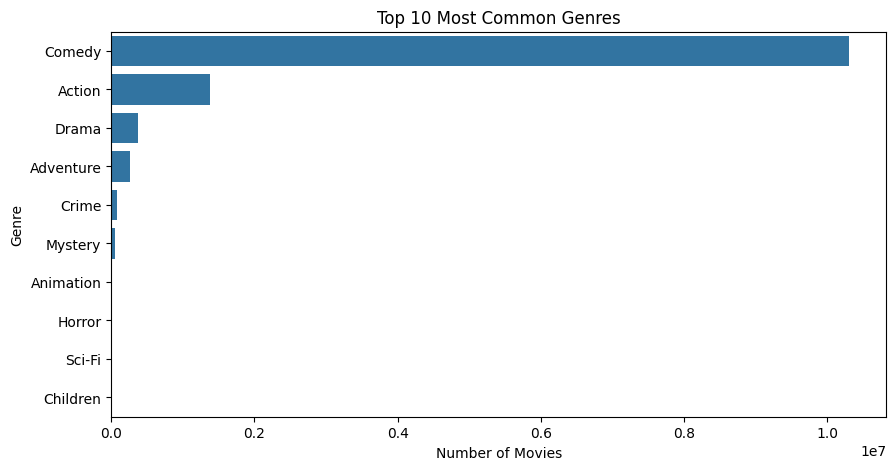

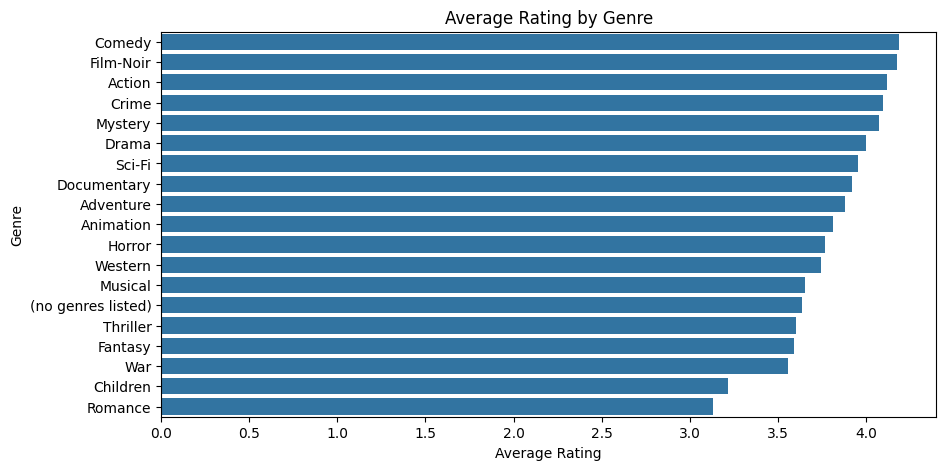

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 most common genres
genre_counts = df['main_genre'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Top 10 Most Common Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

# Average rating by genre
avg_rating_genre = df.groupby('main_genre')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_rating_genre.values, y=avg_rating_genre.index)
plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()


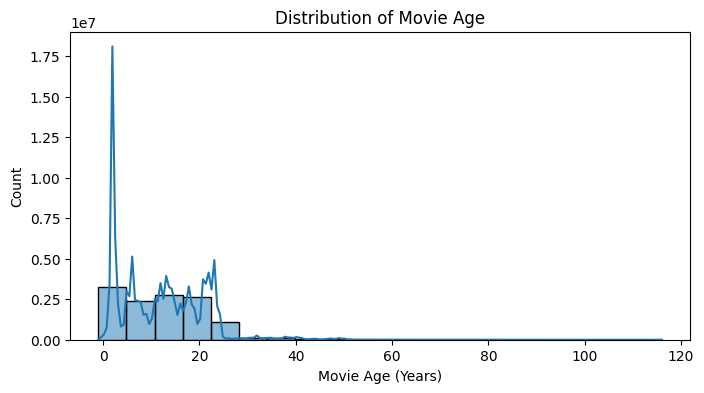

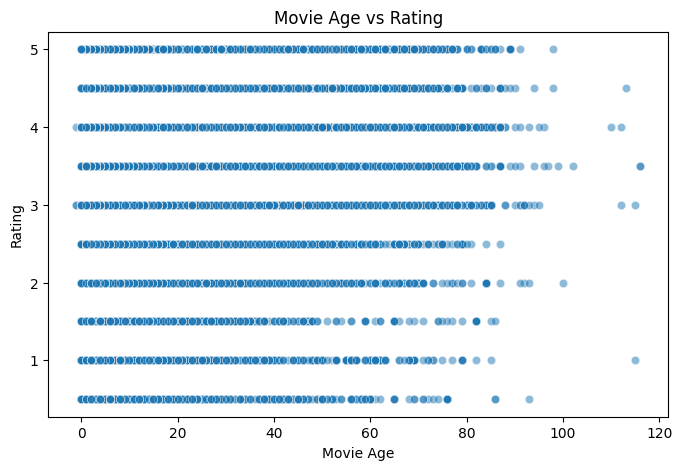

In [ ]:
# Distribution of movie age
plt.figure(figsize=(8, 4))
sns.histplot(df['movie_age'], bins=20, kde=True)
plt.title("Distribution of Movie Age")
plt.xlabel("Movie Age (Years)")
plt.ylabel("Count")
plt.show()

# Relationship between movie age and rating
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='movie_age', y='rating', alpha=0.5)
plt.title("Movie Age vs Rating")
plt.xlabel("Movie Age")
plt.ylabel("Rating")
plt.show()


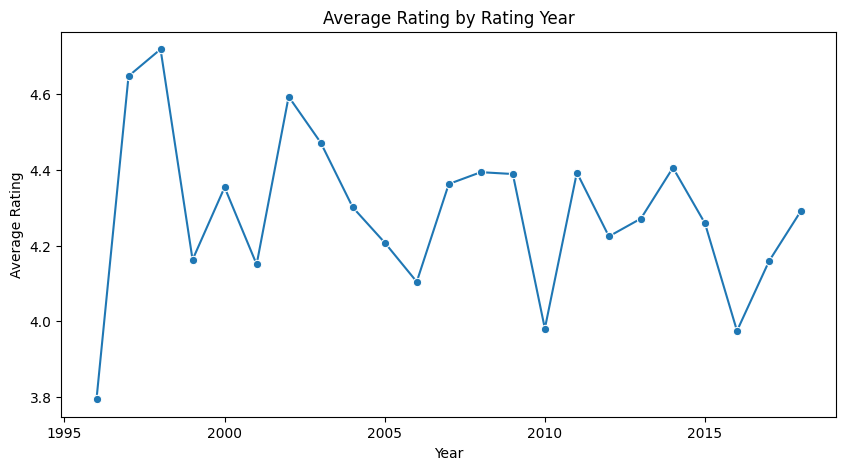

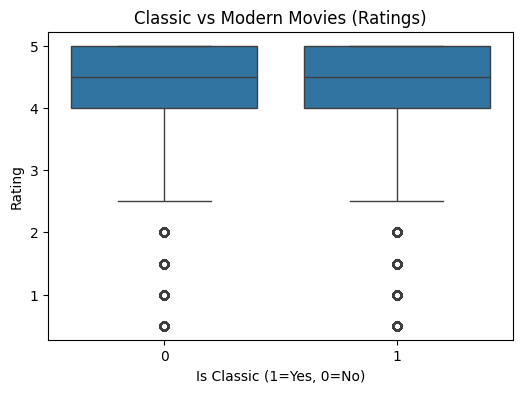

In [ ]:
# Average rating by rating year
rating_trend = df.groupby('rating_year')['rating'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=rating_trend.index, y=rating_trend.values, marker='o')
plt.title("Average Rating by Rating Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()

# Classic vs Modern movies
plt.figure(figsize=(6, 4))
sns.boxplot(x='is_classic', y='rating', data=df)
plt.title("Classic vs Modern Movies (Ratings)")
plt.xlabel("Is Classic (1=Yes, 0=No)")
plt.ylabel("Rating")
plt.show()


In [ ]:
import zipfile

with zipfile.ZipFile('movielens_cleaned.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('movielens_cleaned.csv')

from google.colab import files
files.download('movielens_cleaned.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>